# Using `run_hhsa()` With Your Own Data

This notebook is a reusable template for running the HHSA pipeline on your own one-dimensional signal or one selected channel from a multi-channel file.

Supported examples include NumPy arrays (`.npy`, `.npz`), CSV/TXT tables, WAV audio, and MNE-readable FIF EEG/MEG files. If `DATA_PATH` is left as `None`, the notebook uses a synthetic non-stationary signal so you can verify that the workflow is installed correctly.


In [1]:
from pathlib import Path
import sys
import warnings

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "examples":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as scipy_signal
from scipy.io import wavfile
from scipy.signal import detrend, resample_poly, welch

from hhsa import mode_energy, run_hhsa

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})


## 1. Set Your Data Path and Analysis Options

Edit this cell first. For table-like files, `CHANNEL_INDEX` chooses the channel/column to analyze. For MNE FIF files, `MNE_PICKS` can be an MNE picks argument such as `'meg'`, `'eeg'`, a channel name list, or `None`.


In [2]:
# Set this to your file path, or leave None to run the synthetic fallback.
#DATA_PATH = "/Users/kevinhsu/Downloads/sub-01_ses-01_task-listen_run-01_meg.fif"
DATA_PATH = "/Users/kevinhsu/Downloads/ch1-3.wav"

# Choose one of: "auto", "npy", "npz", "csv", "txt", "wav", "mne_fif".
DATA_KIND = "auto"

# Required for NumPy/CSV/TXT input. WAV and MNE FIF files provide their own sample rates.
SAMPLE_RATE = 250.0

# Channel/column selection for array-like input. Use 0 for the first channel.
CHANNEL_INDEX = 0
CHANNEL_AXIS = "auto"  # "auto", "first" for channels x samples, or "last" for samples x channels.

# MNE options for FIF EEG/MEG data.
MNE_PICKS = None

# Optional crop and resampling. Keep short first, then increase after the plots look right.
START_SECONDS = 0.0
DURATION_SECONDS = 8.0
TARGET_SAMPLE_RATE = None

# Optional preprocessing. Use None to skip either filter edge.
LOWPASS_HZ = None
HIGHPASS_HZ = None
ZSCORE_SIGNAL = True

# HHSA settings. Start small for a fast first run.
DECOMPOSITION = "iceemdan"  # "ensemble_sift", "mask_sift", "ceemdan", "iceemdan", "sift".
FREQUENCY_METHOD = "quad"#"hybrid" #
MAX_IMFS = 10
MAX_AM_IMFS = 2
ENSEMBLE_SIZE = 20
NOISE_WIDTH = 0.12
RANDOM_STATE = 42

# For mask_sift only. Frequencies are listed in Hz here and converted to cycles/sample below.
MASK_FREQUENCIES_HZ = np.array([40.0, 24.0, 12.0, 6.0])
MASK_AMP = 1.0
MASK_AMP_MODE = "ratio_sig"


## 2. Loading and Preprocessing Helpers

These functions normalize common file types to a single vector named `signal` and a scalar `sample_rate`, which is the format expected by `run_hhsa()`.


In [3]:
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + np.finfo(float).eps)


def infer_kind(path, kind):
    if kind != "auto":
        return kind
    suffix = Path(path).suffix.lower()
    if suffix == ".npy":
        return "npy"
    if suffix == ".npz":
        return "npz"
    if suffix == ".csv":
        return "csv"
    if suffix in {".txt", ".tsv"}:
        return "txt"
    if suffix == ".wav":
        return "wav"
    if suffix == ".fif":
        return "mne_fif"
    raise ValueError(f"Could not infer DATA_KIND from suffix {suffix!r}; set DATA_KIND explicitly.")


def select_channel(values, channel_index=0, channel_axis="auto"):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return arr
    if arr.ndim != 2:
        raise ValueError("Array input must be one-dimensional or two-dimensional.")
    if channel_axis == "first":
        matrix = arr
    elif channel_axis == "last":
        matrix = arr.T
    elif channel_axis == "auto":
        matrix = arr if arr.shape[0] <= arr.shape[1] else arr.T
    else:
        raise ValueError("CHANNEL_AXIS must be 'auto', 'first', or 'last'.")
    return matrix[int(channel_index)]


def load_from_path(path, kind, sample_rate, channel_index=0, channel_axis="auto", mne_picks=None):
    path = Path(path).expanduser().resolve()
    kind = infer_kind(path, kind)
    if kind == "npy":
        data = np.load(path)
        return select_channel(data, channel_index, channel_axis), float(sample_rate), f"NPY: {path.name}"
    if kind == "npz":
        npz = np.load(path)
        key = list(npz.keys())[0]
        return select_channel(npz[key], channel_index, channel_axis), float(sample_rate), f"NPZ: {path.name}[{key}]"
    if kind in {"csv", "txt"}:
        delimiter = "," if kind == "csv" else None
        data = np.loadtxt(path, delimiter=delimiter)
        return select_channel(data, channel_index, channel_axis), float(sample_rate), f"{kind.upper()}: {path.name}"
    if kind == "wav":
        fs, data = wavfile.read(path)
        arr = np.asarray(data)
        x = arr.astype(float)
        if np.issubdtype(arr.dtype, np.integer):
            x = x / max(1, np.iinfo(arr.dtype).max)
        return select_channel(x, channel_index, "last" if x.ndim == 2 else "auto"), float(fs), f"WAV: {path.name}"
    if kind == "mne_fif":
        import mne

        raw = mne.io.read_raw_fif(path, preload=True, verbose=False, allow_maxshield=True)
        data = raw.get_data(picks=mne_picks)
        names = raw.copy().pick(picks=mne_picks).ch_names if mne_picks is not None else raw.ch_names
        chosen = int(channel_index)
        label = names[chosen] if chosen < len(names) else f"channel_{chosen}"
        return data[chosen], float(raw.info["sfreq"]), f"MNE FIF: {path.name}, {label}"
    raise ValueError(f"Unsupported DATA_KIND: {kind}")


def make_synthetic_signal(seconds=8.0, sample_rate=250.0, random_state=42):
    rng = np.random.default_rng(random_state)
    t = np.arange(int(seconds * sample_rate)) / sample_rate
    slow = 0.35 * np.sin(2 * np.pi * 2.0 * t)
    carrier = (1.0 + 0.45 * np.sin(2 * np.pi * 0.8 * t)) * np.sin(2 * np.pi * 10.0 * t)
    burst = 0.70 * np.exp(-0.5 * ((t - seconds * 0.55) / 0.45) ** 2) * np.sin(2 * np.pi * 24.0 * t)
    noise = 0.18 * rng.normal(size=t.size)
    return slow + carrier + burst + noise, sample_rate, "synthetic fallback signal"


def crop_signal(x, sample_rate, start_seconds=0.0, duration_seconds=None):
    start = max(0, int(round(start_seconds * sample_rate)))
    if duration_seconds is None:
        stop = x.size
    else:
        stop = min(x.size, start + int(round(duration_seconds * sample_rate)))
    return np.asarray(x[start:stop], dtype=float)


def maybe_resample(x, sample_rate, target_sample_rate):
    if target_sample_rate is None or abs(float(target_sample_rate) - float(sample_rate)) < 1e-9:
        return x, float(sample_rate)
    from math import gcd

    old = int(round(sample_rate))
    new = int(round(target_sample_rate))
    factor = gcd(old, new)
    return resample_poly(x, new // factor, old // factor), float(new)


def maybe_filter(x, sample_rate, highpass_hz=None, lowpass_hz=None):
    nyq = sample_rate / 2.0
    if highpass_hz is None and lowpass_hz is None:
        return x
    if highpass_hz is not None and lowpass_hz is not None:
        sos = scipy_signal.butter(4, [highpass_hz / nyq, lowpass_hz / nyq], btype="bandpass", output="sos")
    elif highpass_hz is not None:
        sos = scipy_signal.butter(4, highpass_hz / nyq, btype="highpass", output="sos")
    else:
        sos = scipy_signal.butter(4, lowpass_hz / nyq, btype="lowpass", output="sos")
    return scipy_signal.sosfiltfilt(sos, x)


In [ ]:
print(raw.ch_names)

## 3. Load Your Signal

After this cell, `raw_signal` is the selected channel before preprocessing, and `signal` is the cropped/resampled/filtered/scaled input passed to `run_hhsa()`.


In [4]:
if DATA_PATH is None:
    raw_signal, sample_rate_meg, source = make_synthetic_signal(seconds=DURATION_SECONDS, sample_rate=SAMPLE_RATE, random_state=RANDOM_STATE)
else:
    raw_signal, sample_rate_meg, source = load_from_path(
        DATA_PATH,
        DATA_KIND,
        SAMPLE_RATE,
        channel_index=CHANNEL_INDEX,
        channel_axis=CHANNEL_AXIS,
        mne_picks=MNE_PICKS,
    )

signal = crop_signal(raw_signal, sample_rate_meg, START_SECONDS, DURATION_SECONDS)
signal, sample_rate = maybe_resample(signal, sample_rate_meg, TARGET_SAMPLE_RATE)
signal = detrend(np.asarray(signal, dtype=float))
signal = maybe_filter(signal, sample_rate_meg, highpass_hz=HIGHPASS_HZ, lowpass_hz=LOWPASS_HZ)
if ZSCORE_SIGNAL:
    signal = zscore(signal)

time = np.arange(signal.size) / sample_rate
print(source)
print(f"samples={signal.size}, sample_rate={sample_rate_meg:.3f} Hz, duration={signal.size / sample_rate_meg:.3f} s")
print(f"finite={np.isfinite(signal).all()}, mean={np.mean(signal):.3g}, std={np.std(signal):.3g}")


WAV: ch1-3.wav
samples=352800, sample_rate=44100.000 Hz, duration=8.000 s
finite=True, mean=8.86e-19, std=1


In [ ]:
print(DATA_PATH.info)

## 4. Input Quality Checks

Use these plots to confirm that the selected channel and preprocessing are sensible before decomposition. The PSD and spectrogram help you choose `carrier_hist`, `am_hist`, and optional mask frequencies.


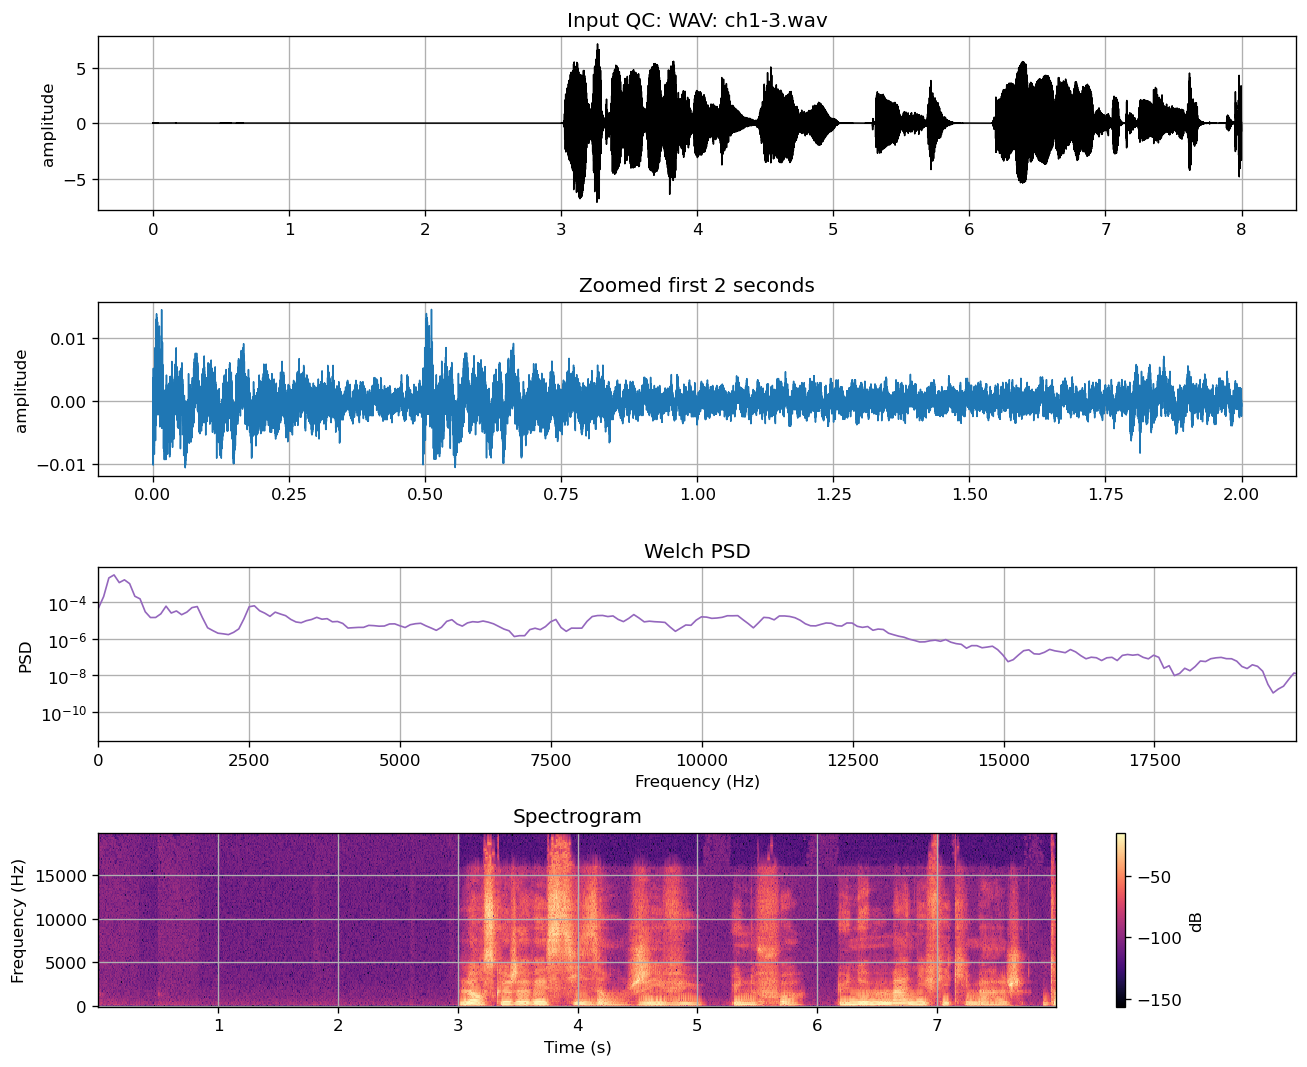

In [5]:
def plot_input_qc(x, sample_rate, title="Input QC"):
    t = np.arange(x.size) / sample_rate
    freqs, psd = welch(x, fs=sample_rate, nperseg=min(512, x.size))
    f, tt, sxx = scipy_signal.spectrogram(x, fs=sample_rate, nperseg=min(256, x.size), noverlap=min(128, max(0, x.size // 4)))
    upper = min(sample_rate / 2.0, max(10.0, sample_rate * 0.45))

    fig, axes = plt.subplots(4, 1, figsize=(11, 9))
    axes[0].plot(t, x, color="black", linewidth=0.9)
    axes[0].set_title(title)
    axes[0].set_ylabel("amplitude")

    zoom_n = min(x.size, int(2.0 * sample_rate))
    axes[1].plot(t[:zoom_n], x[:zoom_n], color="tab:blue", linewidth=0.9)
    axes[1].set_title("Zoomed first 2 seconds")
    axes[1].set_ylabel("amplitude")

    axes[2].semilogy(freqs, psd, color="tab:purple", linewidth=1.0)
    axes[2].set_xlim(0, upper)
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("PSD")
    axes[2].set_title("Welch PSD")

    keep = f <= upper
    im = axes[3].pcolormesh(tt, f[keep], 10 * np.log10(sxx[keep] + np.finfo(float).eps), shading="auto", cmap="magma")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("Frequency (Hz)")
    axes[3].set_title("Spectrogram")
    fig.colorbar(im, ax=axes[3], label="dB")
    fig.tight_layout()
    return fig, axes


plot_input_qc(signal, sample_rate_meg, title=f"Input QC: {source}");


## 5. Run `run_hhsa()`

`run_hhsa()` returns an `HHSAResult` containing first-layer IMFs, residue, instantaneous amplitude/frequency, second-layer amplitude-modulation IMFs, HHT, and Holo-Hilbert spectra.


In [ ]:
# Before calling run_hhsa:
sample_rate=sample_rate
if np.allclose(signal, 0) or signal.size < 10:
    print("Signal is too flat or too short for decomposition!")
else:
    # Pass your actual 'signal' and 'sample_rate' variables here!
    result = run_hhsa(
        signal,                # 1st positional argument
        sample_rate=sample_rate_meg,           # 2nd positional argument
        decomposition='iceemdan', # Keyword arguments go here...
        emd_backend="pyemd",
        frequency_method='hybrid'
    )

In [ ]:
print(type(sample_rate_meg))

In [6]:
carrier_low = max(sample_rate / signal.size, 1e-6)
carrier_high = sample_rate / 2.0
am_low = max(sample_rate / signal.size, 1e-6)
am_high = sample_rate / 4.0
#try:
result = run_hhsa(
    signal=signal,
    sample_rate=sample_rate_meg,
    decomposition=DECOMPOSITION,
    frequency_method=FREQUENCY_METHOD,
    max_imfs=MAX_IMFS,
    max_am_imfs=MAX_AM_IMFS,
    ensemble_size=ENSEMBLE_SIZE,
    noise_width=NOISE_WIDTH,
    random_state=RANDOM_STATE,
    carrier_hist=(carrier_low, carrier_high, 128, "log"),
    am_hist=(am_low, am_high, 64, "log"),
    mask_freqs=MASK_FREQUENCIES_HZ / sample_rate if DECOMPOSITION in {"mask_sift", "iterated_mask_sift"} else None,
    mask_amp=MASK_AMP,
    mask_amp_mode=MASK_AMP_MODE,
)

print(f"IMFs: {result.imfs.shape}")
print(f"Residue: {result.residue.shape}")
print(f"Reconstruction error: {result.reconstruction_error:.3e}")
print(f"HHT: {result.hht.shape}")
print(f"Holospectrum: {result.holospectrum.shape}")

# except UnboundLocalError:
#     print("Skipping segment: Signal too quiet for EMD.")
#     result = None # Or handle as needed


KeyboardInterrupt: 

## 6. First-Layer Decomposition and Reconstruction Check

The signal should be closely reconstructed by the sum of IMFs plus the residue. A large mismatch usually points to a shape, scaling, or preprocessing problem.


In [ ]:
def plot_decomposition(result, max_modes=None):
    n_modes = result.imfs.shape[0] if max_modes is None else min(max_modes, result.imfs.shape[0])
    rows = n_modes + 3
    t = np.arange(result.signal.size) / result.sample_rate
    fig, axes = plt.subplots(rows, 1, sharex=True, figsize=(11, max(6, 1.35 * rows)))
    axes[0].plot(t, result.signal, color="black", linewidth=0.9)
    axes[0].set_title(f"{DECOMPOSITION}: signal, IMFs, and residue")
    axes[0].set_ylabel("signal")
    for idx in range(n_modes):
        axes[idx + 1].plot(t, result.imfs[idx], linewidth=0.9)
        axes[idx + 1].set_ylabel(f"IMF {idx + 1}")
    axes[n_modes + 1].plot(t, result.residue, color="tab:red", linewidth=0.9)
    axes[n_modes + 1].set_ylabel("residue")
    axes[-1].plot(t, result.signal, color="black", linewidth=1.0, label="signal")
    axes[-1].plot(t, result.reconstruction, color="tab:green", linewidth=0.9, alpha=0.85, label="IMFs + residue")
    axes[-1].set_title(f"relative reconstruction error = {result.reconstruction_error:.3e}")
    axes[-1].set_xlabel("Time (s)")
    axes[-1].legend(loc="upper right")
    fig.tight_layout()
    return fig, axes


plot_decomposition(result, max_modes=MAX_IMFS);


## 7. Instantaneous Amplitude and Frequency Check

Amplitude should be non-negative. Frequency tracks should mostly remain within the meaningful range for your data, although endpoint spikes can occur with Hilbert-based estimates.


In [ ]:
def plot_am_fm(result, max_modes=None, max_frequency=None):
    n_modes = result.imfs.shape[0] if max_modes is None else min(max_modes, result.imfs.shape[0])
    if n_modes == 0:
        print("No IMFs were extracted.")
        return None, None
    max_frequency = sample_rate / 2.0 if max_frequency is None else min(max_frequency, sample_rate / 2.0)
    t = np.arange(result.signal.size) / result.sample_rate
    fig, axes = plt.subplots(n_modes, 2, sharex=True, figsize=(12, max(5, 1.9 * n_modes)))
    if n_modes == 1:
        axes = np.asarray([axes])
    for idx in range(n_modes):
        axes[idx, 0].plot(t, result.amplitude[idx], color="tab:blue", linewidth=0.9)
        axes[idx, 0].set_ylabel(f"IMF {idx + 1}")
        axes[idx, 0].set_title("Instantaneous amplitude" if idx == 0 else "")
        axes[idx, 1].plot(t, np.clip(result.frequency[idx], 0, max_frequency), color="tab:orange", linewidth=0.9)
        axes[idx, 1].set_ylim(0, max_frequency)
        axes[idx, 1].set_title("Instantaneous frequency" if idx == 0 else "")
    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    fig.tight_layout()
    fig.savefig("MEGtest_am_fm_plot.png", dpi=300, bbox_inches="tight")
    return fig, axes


plot_am_fm(result, max_modes=MAX_IMFS, max_frequency=carrier_high);


## 8. Second-Layer Amplitude-Modulation Check

HHSA decomposes each carrier IMF's amplitude envelope. This cell displays the strongest carrier IMF by energy.


In [ ]:
def plot_second_layer(result, carrier_index=None, max_am_modes=None):
    if result.imfs.size == 0:
        print("No first-layer IMFs were extracted.")
        return None, None
    if carrier_index is None:
        carrier_index = int(np.argmax(mode_energy(result.imfs)))
    am_modes = result.am_imfs[carrier_index]
    am_residue = result.am_residues[carrier_index]
    envelope = result.amplitude[carrier_index]
    n_modes = am_modes.shape[0] if max_am_modes is None else min(max_am_modes, am_modes.shape[0])
    t = np.arange(result.signal.size) / result.sample_rate
    fig, axes = plt.subplots(n_modes + 2, 1, sharex=True, figsize=(11, max(5, 1.4 * (n_modes + 2))))
    axes[0].plot(t, envelope, color="tab:blue", linewidth=0.9)
    axes[0].set_title(f"Second-layer AM decomposition from carrier IMF {carrier_index + 1}")
    axes[0].set_ylabel("envelope")
    for idx in range(n_modes):
        axes[idx + 1].plot(t, am_modes[idx], linewidth=0.9)
        axes[idx + 1].set_ylabel(f"AM IMF {idx + 1}")
    axes[-1].plot(t, am_residue, color="tab:red", linewidth=0.9)
    axes[-1].set_ylabel("AM residue")
    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    return fig, axes


plot_second_layer(result, max_am_modes=MAX_AM_IMFS);


## 9. Hilbert-Huang and Holo-Hilbert Spectra

The marginal HHT summarizes carrier frequencies. The HHT image shows carrier activity over time, and the holospectrum summarizes which amplitude-modulation frequencies are associated with each carrier band.


In [ ]:
def plot_spectra(result):
    t = np.arange(result.signal.size) / result.sample_rate
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(result.carrier_bins, result.marginal, color="black", linewidth=1.0)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Carrier frequency (Hz)")
    axes[0].set_ylabel("Power")
    axes[0].set_title("Marginal HHT")
    im0 = axes[1].imshow(
        result.hht,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], result.carrier_bins[0], result.carrier_bins[-1]],
        cmap="magma",
    )
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Carrier frequency (Hz)")
    axes[1].set_title("Hilbert-Huang spectrum")
    fig.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    im1 = axes[2].imshow(
        result.holospectrum,
        aspect="auto",
        origin="lower",
        extent=[result.am_bins[0], result.am_bins[-1], result.carrier_bins[0], result.carrier_bins[-1]],
        cmap="viridis",
    )
    axes[2].set_xscale("log")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("AM frequency (Hz)")
    axes[2].set_ylabel("Carrier frequency (Hz)")
    axes[2].set_title("Time-averaged holospectrum")
    fig.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig, axes


plot_spectra(result);


## 10. Compact Numerical Summary

Use this output for quick regression checks when you change preprocessing, decomposition method, or HHSA parameters.


In [ ]:
energies = mode_energy(result.imfs)
dominant_idx = int(np.argmax(result.marginal)) if result.marginal.size else -1
dominant_frequency = result.carrier_bins[dominant_idx] if dominant_idx >= 0 else np.nan

print(f"decomposition: {DECOMPOSITION}")
print(f"n_imfs: {result.imfs.shape[0]}")
print(f"reconstruction_error: {result.reconstruction_error:.3e}")
print(f"dominant_hht_frequency_hz: {dominant_frequency:.3f}")
print(f"mode_energy: {np.round(energies, 4).tolist()}")

fig, ax = plt.subplots(figsize=(7, 3.5))
if energies.size:
    ax.bar(np.arange(1, energies.size + 1), energies / (np.sum(energies) + np.finfo(float).eps), color="tab:blue")
ax.set_xlabel("IMF")
ax.set_ylabel("Normalized energy")
ax.set_title("Energy by IMF")
fig.tight_layout();


## Practical Notes

- Start with a short segment and small `ENSEMBLE_SIZE` until the plots look reasonable.
- Increase `ENSEMBLE_SIZE` to 50-200 for more stable CEEMDAN/ICEEMDAN results.
- For `mask_sift`, tune `MASK_FREQUENCIES_HZ` to the expected frequency bands in your signal.
- Check reconstruction error every time you change preprocessing or decomposition parameters.
- Interpret the first and last few samples cautiously because EMD-style envelope fitting can show endpoint artifacts.
